In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()


In [7]:
  cursor.execute('''
    CREATE TABLE IF NOT EXISTS sales (
        id INTEGER PRIMARY KEY,
        product TEXT,
        quantity INTEGER,
        price REAL
    )
''')

In [11]:
sample_data = [
    ('Apple', 10, 0.5),
    ('Banana', 20, 0.2),
    ('Orange', 15, 0.3),
    ('Apple', 5, 0.5),
    ('Banana', 10, 0.2),
    ('Orange', 10, 0.3)
]
cursor.executemany('INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)', sample_data)
conn.commit()

In [13]:
query = """
SELECT
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

df = pd.read_sql_query(query, conn)

In [14]:
print("Sales Summary:")
print(df)

Sales Summary:
  product  total_qty  revenue
0   Apple         30     15.0
1  Banana         60     12.0
2  Orange         50     15.0


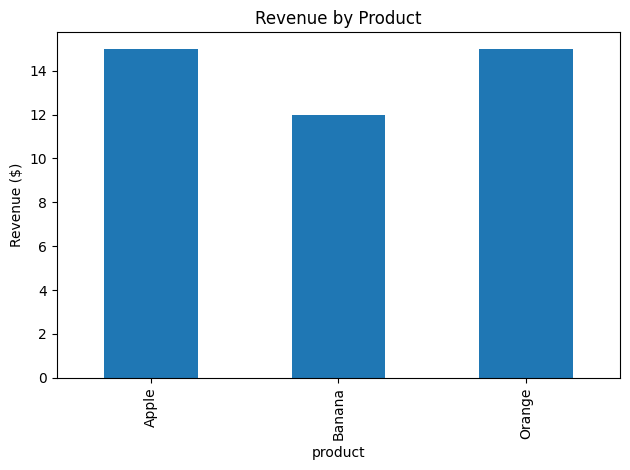

In [15]:
df.plot(kind='bar', x='product', y='revenue', legend=False)
plt.ylabel('Revenue ($)')
plt.title('Revenue by Product')
plt.tight_layout()

In [17]:
conn.close()